In [1]:
import torch
from equiv_dens.training.parse_command_line_arguments import parse_command_line_arguments
from equiv_dens.training.errors import ErrorDict
from equiv_dens.data.density_dataset import AtomsDensityData
from equiv_dens.data.hamiltonian_dataset import seeded_random_split
from equiv_dens.utils.grids import cubical_grid, cubical_sampling,\
    dftpy_grid, CubicalGrid, spherical_grid, spherical_radial_sampling
from equiv_dens.training.model_loader import load_model
import equiv_dens.utils.base as utils
from equiv_dens.utils import orbitals
from functools import partial
import os
import numpy as np

%load_ext autoreload
%autoreload 2

Use "numpy" for Fourier Transform


/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/pyscf/lib/misc.py:47: H5pyDeprecationWarning: Using default_file_mode other than 'r' is deprecated. Pass the mode to h5py.File() instead.
  h5py.get_config().default_file_mode = 'a'


In [4]:
args, hyperparam_args = parse_command_line_arguments(arg_file='C_dens.txt')

print('type dtype', type(args.dtype))
args.fix_arguments = True
print('args np dir', args.np_dataset)
# no restart directory specified
directory = args.restart  # load directory name
# load latest checkpoint
checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
checkpoint = torch.load(os.path.join(
    checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['step']
model_code = checkpoint['ID']  # load ID
step = checkpoint['step']
for arg in vars(checkpoint['args']):
    if args.fix_arguments:
        if arg in hyperparam_args:
            print('loading hyperparam arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    else:
        print('loading all arg', arg)
        setattr(args, arg, getattr(checkpoint['args'], arg))
restore = True

args.best_model_path = 'best_' + model_code + '.pth'
print('best_model_path', args.best_model_path)

print('model code:', model_code)
# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = False
# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")

args.radial_coeffs_file = 'datasets/augccpvqzjkfit_radial_coeffs_libcint_df.npy'

args.verbose = 0
args.use_gpu = False
args.cube_grid = False 
args.radii_adjust = True 
args.expansion_constraint=None
if args.cube_grid:
    args.cube_origin = -0.25
    args.cube_extent = 0.5
    args.cube_size = 50
    args.radii_adjust = False
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    grid_fn = partial(spherical_grid, level=4)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

    
dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust)

dataset_df = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust,
                           projected_density=True)
    
#dataset_df.density_fitting[0]['df_coeff'] *= 0
sample = dataset.get_properties([0])
sample_df = dataset_df.get_properties([0])
print('density loss', torch.sum(torch.abs(sample['density'] - sample_df['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
print(dataset_df.density_fitting)
print(dataset.atoms)
args.restart = None
model = load_model(args, dataset)
result = model(sample)
print('ml density loss', torch.sum(torch.abs(sample['density'] - result['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('ml density integral', torch.sum(result['density'] * sample['coord_weights']))

type dtype <class 'torch.dtype'>
args np dir datasets/C_augccpvdz.npy
loading hyperparam arg activation
loading hyperparam arg order
loading hyperparam arg mixing_order
loading hyperparam arg order_en
loading hyperparam arg mixing_order_en
loading hyperparam arg num_features
loading hyperparam arg num_basis_functions
loading hyperparam arg num_radial_components
loading hyperparam arg num_energy_features
loading hyperparam arg num_modules
loading hyperparam arg num_residual_pre_x
loading hyperparam arg num_residual_post_x
loading hyperparam arg num_residual_pre_vi
loading hyperparam arg num_residual_pre_vj
loading hyperparam arg num_residual_post_v
loading hyperparam arg num_residual_output
loading hyperparam arg num_energy_output
loading hyperparam arg basis_functions
loading hyperparam arg cutoff
loading hyperparam arg orthonormal_basis
loading hyperparam arg expansion_constraint
loading hyperparam arg integral_constraint
loading hyperparam arg integral_scale
loading hyperparam arg in

In [3]:
sample_idx = 0
bas_idx = 5
for bas_idx in range(9,10):
    dataset_df.density_fitting[sample_idx]['df_coeff'] = torch.tensor(dataset_df.density_fitting[sample_idx]['df_coeff']).to(sample['positions']).view(1, -1)
    dataset_df.density_fitting[sample_idx]['df_coeff'] *= 0
    dataset_df.density_fitting[sample_idx]['df_coeff'][:, bas_idx] = 1 

    sample_df = dataset_df.get_properties([sample_idx])
    df_integral =  torch.sum(sample_df['density'] * sample_df['coord_weights'])
    print('df integral', torch.sum(sample_df['density'] * sample_df['coord_weights']))

    coeffs = orbitals.vector_to_coeffs_dict({'spherical_coeffs': dataset_df.density_fitting[sample_idx]['df_coeff']}, model.density_repr_model[0].orbital_basis,
                                             result['atom_numbers'], radial_coeffs=False)
    sample['spherical_coeffs'] = coeffs['spherical_coeffs']
    sample['radial_width'] = [{key:result['radial_width'][i][key]*sample_idx for key in result['radial_width'][i].keys()} for i in range(len(result['radial_width']))]
    sample['radial_scale'] = [{key:result['radial_scale'][i][key]*sample_idx for key in result['radial_scale'][i].keys()} for i in range(len(result['radial_scale']))]
    # sample['radial_scale'] = result['radial_scale']
    # print('spherical coeffs', sample['spherical_coeffs'])
    res = model.property_models['density'](sample)

    mol = dataset_df.mols[sample_idx]
    if not mol._built and mol.basis != dataset_df.density_fitting[sample_idx]['auxbasis']:
        mol.basis = self.density_fitting[sample_idx]['auxbasis']
        # build_start = time.time()
        mol.build()
    ctr_coeff = mol._libcint_ctr_coeff(bas_idx)
    print('mol_env', mol._env)
    print('contracted coeff', ctr_coeff)
    print('density shape', res['density'].shape)
    res_density = res['density']
    #res_density = res['density']
    ml_integral = torch.sum(res_density * sample_df['coord_weights'])
    print('ml integral', ml_integral)
    ratio = ml_integral/df_integral
    print('ratio', float(ratio))
    print('density diff', torch.mean(torch.abs(res_density - sample_df['density']) * sample['coord_weights']) / df_integral)
    print('ratio 1000', float(res_density[:, 1000]/sample_df['density'][:, 1000]))
    print('density diff 1000', torch.abs(res_density[:, 1000] - sample_df['density'][:, 1000]))
    print(sample_df['coords'])
    print(sample_df['coord_weights'])

df integral tensor(13.6902)
L 1
scale tensor([[[[9.5717e+02, 1.8902e+02, 5.0820e+01, 1.3217e+01, 4.8217e+00,
           1.4668e+00, 3.9801e-01, 1.0800e-01]]]], grad_fn=<MulBackward0>)
width tensor([[[[1.0299e+02, 2.8133e+01, 9.8364e+00, 3.3491e+00, 1.4948e+00,
           5.7690e-01, 2.0320e-01, 7.1573e-02]]]], grad_fn=<MulBackward0>)
scale calc tensor([[[[2.7001e+02, 5.3320e+01, 1.4336e+01, 3.7285e+00, 1.3602e+00,
           4.1377e-01, 1.1228e-01, 3.0466e-02]]]], grad_fn=<DivBackward0>)
rbf integral tensor([[2.0950e-02, 1.0609e-01, 3.9459e-01, 1.5172e+00, 4.1589e+00, 1.3672e+01,
         5.0384e+01, 1.8568e+02]], grad_fn=<SumBackward1>)
L 2
scale tensor([[[[1.6233e+02, 2.4547e+01, 4.3296e+00, 8.2947e-01, 1.5545e-01,
           2.9132e-02]]]], grad_fn=<MulBackward0>)
width tensor([[[[10.5941,  3.5997,  1.3356,  0.5195,  0.1995,  0.0766]]]],
       grad_fn=<MulBackward0>)
scale calc tensor([[[[4.5791e+01, 6.9246e+00, 1.2214e+00, 2.3399e-01, 4.3851e-02,
           8.2180e-03]]]], grad_fn

In [78]:
import pyscf
print(pyscf.lib.param.BOHR)
print(pyscf.lib.param.)

SyntaxError: invalid syntax (<ipython-input-78-d14bf128545c>, line 3)

In [38]:
print(utils.to_angstrom)

0.52917721092


In [39]:
print(sample['coord_weights'])
print(sample_df['coord_weights'])
print(sample['coords'])
print(sample_df['coords'])

tensor([[6.3595e-17, 2.4674e-14, 8.0639e-13,  ..., 7.3571e-02, 8.5789e-02,
         1.0018e-01]])
tensor([[6.3595e-17, 2.4674e-14, 8.0639e-13,  ..., 7.3571e-02, 8.5789e-02,
         1.0018e-01]])
tensor([[[ 2.6427e-06,  0.0000e+00,  0.0000e+00],
         [ 2.4284e-05,  0.0000e+00,  0.0000e+00],
         [ 8.8878e-05,  0.0000e+00,  0.0000e+00],
         ...,
         [-1.8062e+00, -1.8914e-01, -1.0579e+00],
         [-1.9022e+00, -1.9920e-01, -1.1142e+00],
         [-2.0033e+00, -2.0978e-01, -1.1734e+00]]])
tensor([[[ 2.6427e-06,  0.0000e+00,  0.0000e+00],
         [ 2.4284e-05,  0.0000e+00,  0.0000e+00],
         [ 8.8878e-05,  0.0000e+00,  0.0000e+00],
         ...,
         [-1.8062e+00, -1.8914e-01, -1.0579e+00],
         [-1.9022e+00, -1.9920e-01, -1.1142e+00],
         [-2.0033e+00, -2.0978e-01, -1.1734e+00]]])


In [40]:
(1-0.9927)/11000

6.636363636363612e-07

In [20]:
print('df max', torch.max(sample_df['density']))
print('pred max', torch.max(res_density))
print('ratio max', torch.max(res_density)/torch.max(sample_df['density']))
print('df 10', sample_df['density'][:, 10])
print('pred 10', res_density[:, 10])
print('pred 10', res_density[:, 10])
print('ratio 10', res_density[:, 10]/sample_df['density'][:, 10])
print('df 1000', sample_df['density'][:, 1000])
print('pred 1000', res_density[:, 1000])
print('pred 1000', res_density[:, 1000])
print('ratio 1000', res_density[:, 1000]/sample_df['density'][:, 1000])

df max tensor(0.2066)
pred max tensor(0.0151, grad_fn=<MaxBackward1>)
ratio max tensor(0.0730, grad_fn=<DivBackward0>)
df 10 tensor([0.2066])
pred 10 tensor([0.0151], grad_fn=<SelectBackward0>)
pred 10 tensor([0.0151], grad_fn=<SelectBackward0>)
ratio 10 tensor([0.0730], grad_fn=<DivBackward0>)
df 1000 tensor([0.2065])
pred 1000 tensor([0.0151], grad_fn=<SelectBackward0>)
pred 1000 tensor([0.0151], grad_fn=<SelectBackward0>)
ratio 1000 tensor([0.0730], grad_fn=<DivBackward0>)


In [55]:
args, hyperparam_args = parse_command_line_arguments(arg_file='C_dens.txt')

print('type dtype', type(args.dtype))
args.fix_arguments = True
print('args np dir', args.np_dataset)
# no restart directory specified
directory = args.restart  # load directory name
# load latest checkpoint
checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
checkpoint = torch.load(os.path.join(
    checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['step']
model_code = checkpoint['ID']  # load ID
step = checkpoint['step']
for arg in vars(checkpoint['args']):
    if args.fix_arguments:
        if arg in hyperparam_args:
            print('loading hyperparam arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    else:
        print('loading all arg', arg)
        setattr(args, arg, getattr(checkpoint['args'], arg))
restore = True

args.best_model_path = 'best_' + model_code + '.pth'
print('best_model_path', args.best_model_path)

print('model code:', model_code)
# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = False
# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")

args.verbose = 0
args.use_gpu = False
args.cube_grid = True 
args.radii_adjust = True 
args.expansion_constraint=None
if args.cube_grid:
    args.cube_origin = -0.25
    args.cube_extent = 0.5
    args.cube_size = 50
    args.radii_adjust = False
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    grid_fn = partial(spherical_grid, level=4)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

    
dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust)

dataset_df = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust,
                           projected_density=True)
    
#dataset_df.density_fitting[0]['df_coeff'] *= 0
sample = dataset.get_properties([0])
sample_df = dataset_df.get_properties([0])
print('density loss', torch.sum(torch.abs(sample['density'] - sample_df['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
print(dataset_df.density_fitting)
print(dataset.atoms)
model = load_model(args, dataset)
result = model(sample)
print('ml density loss', torch.sum(torch.abs(sample['density'] - result['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('ml density integral', torch.sum(result['density'] * sample['coord_weights']))

type dtype <class 'torch.dtype'>
args np dir datasets/C_augccpvdz.npy
loading hyperparam arg activation
loading hyperparam arg order
loading hyperparam arg mixing_order
loading hyperparam arg order_en
loading hyperparam arg mixing_order_en
loading hyperparam arg num_features
loading hyperparam arg num_basis_functions
loading hyperparam arg num_radial_components
loading hyperparam arg num_energy_features
loading hyperparam arg num_modules
loading hyperparam arg num_residual_pre_x
loading hyperparam arg num_residual_post_x
loading hyperparam arg num_residual_pre_vi
loading hyperparam arg num_residual_pre_vj
loading hyperparam arg num_residual_post_v
loading hyperparam arg num_residual_output
loading hyperparam arg num_energy_output
loading hyperparam arg basis_functions
loading hyperparam arg cutoff
loading hyperparam arg orthonormal_basis
loading hyperparam arg expansion_constraint
loading hyperparam arg integral_constraint
loading hyperparam arg integral_scale
loading hyperparam arg in

In [57]:
sample_idx = 0
bas_idx = 9
dataset_df.density_fitting[sample_idx]['df_coeff'] = torch.tensor(dataset_df.density_fitting[sample_idx]['df_coeff']).to(sample['positions']).view(1, -1)
dataset_df.density_fitting[sample_idx]['df_coeff'] *= 0
dataset_df.density_fitting[sample_idx]['df_coeff'][:, bas_idx] = 1 

sample_df = dataset_df.get_properties([sample_idx])
df_integral =  torch.sum(sample_df['density'] * sample_df['coord_weights'])
print('df integral', torch.sum(sample_df['density'] * sample_df['coord_weights']))

dataset_df.density_fitting[sample_idx]['df_coeff'] = torch.tensor(dataset_df.density_fitting[sample_idx]['df_coeff']).to(sample['positions']).view(1, -1)
dataset_df.density_fitting[sample_idx]['df_coeff'] *= 0
dataset_df.density_fitting[sample_idx]['df_coeff'][:, 9] = 1 

coeffs = orbitals.vector_to_coeffs_dict({'spherical_coeffs': dataset_df.density_fitting[sample_idx]['df_coeff']}, model.density_repr_model[0].orbital_basis,
                                         result['atom_numbers'], radial_coeffs=False)
sample['spherical_coeffs'] = coeffs['spherical_coeffs']
sample['radial_width'] = [{key:result['radial_width'][i][key]*sample_idx for key in result['radial_width'][i].keys()} for i in range(len(result['radial_width']))]
sample['radial_scale'] = [{key:result['radial_scale'][i][key]*sample_idx for key in result['radial_scale'][i].keys()} for i in range(len(result['radial_scale']))]
# sample['radial_scale'] = result['radial_scale']
# print('spherical coeffs', sample['spherical_coeffs'])
res = model.property_models['density'](sample)

mol = dataset_df.mols[sample_idx]
if not mol._built and mol.basis != dataset_df.density_fitting[sample_idx]['auxbasis']:
    mol.basis = self.density_fitting[sample_idx]['auxbasis']
    # build_start = time.time()
    mol.build()
ctr_coeff = mol._libcint_ctr_coeff(10)
print('contracted coeff', ctr_coeff)
print('contracted coeff 10', mol._libcint_ctr_coeff(10))
print('contracted coeff 11', mol._libcint_ctr_coeff(11))
print('contracted coeff 12', mol._libcint_ctr_coeff(12))
print('density shape', res['density'].shape)
ratio_factor = 3.5449070930480957
res_density = res['density'] * float(ctr_coeff) / ratio_factor
res_density = res['density']
ml_integral = torch.sum(res_density * sample_df['coord_weights'])
print('ml integral', ml_integral)
ratio = ml_integral/df_integral
print('ratio', float(ratio))
print('density diff', torch.mean(torch.abs(res_density - sample_df['density']) * sample['coord_weights']) / df_integral)
print('pred max', torch.max(res_density), '; df max', torch.max(sample_df['density']))
print('ratio max', float(torch.max(res_density)/torch.max(sample_df['density'])))
print('density diff max', torch.abs(torch.max(res_density) - torch.max(sample_df['density'])))
print(sample_df['coords'])
print(sample_df['coord_weights'])

/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/ipykernel_launcher.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  This is separate from the ipykernel package so we can avoid doing imports until
/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/ipykernel_launcher.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  # This is added back by InteractiveShellApp.init_path()


df integral tensor(0.1667)
order 1
scale tensor([[[[1., 1., 1., 1., 1., 1., 1., 1.]]]], grad_fn=<MulBackward0>)
width tensor([[[[1.0299e+02, 2.8133e+01, 9.8364e+00, 3.3491e+00, 1.4948e+00,
           5.7690e-01, 2.0320e-01, 7.1573e-02]]]], grad_fn=<MulBackward0>)
scale calc tensor([[[[1.8771e+02, 2.6797e+01, 5.5403e+00, 1.1007e+00, 3.2820e-01,
           7.8691e-02, 1.6450e-02, 3.4387e-03]]]], grad_fn=<MulBackward0>)
L 1
rbf integral tensor([[0.1046, 0.1998, 0.2821, 0.1898, 0.0874, 0.0264, 0.0061, 0.0013]],
       grad_fn=<SumBackward1>)
order 2
scale tensor([[[[1., 1., 1., 1., 1., 1.]]]], grad_fn=<MulBackward0>)
width tensor([[[[10.5941,  3.5997,  1.3356,  0.5195,  0.1995,  0.0766]]]],
       grad_fn=<MulBackward0>)
scale calc tensor([[[[6.1925e+00, 1.2265e+00, 2.7719e-01, 6.7244e-02, 1.6008e-02,
           3.8106e-03]]]], grad_fn=<MulBackward0>)
L 2
rbf integral tensor([[0.1039, 0.0906, 0.0371, 0.0113, 0.0030, 0.0007]],
       grad_fn=<SumBackward1>)
order 3
scale tensor([[[[1., 1., 

idx [    23   2523   5023 ... 119973 122473 124973]
coords space shape torch.Size([1, 125000, 3])
torch.Size([1, 125000])


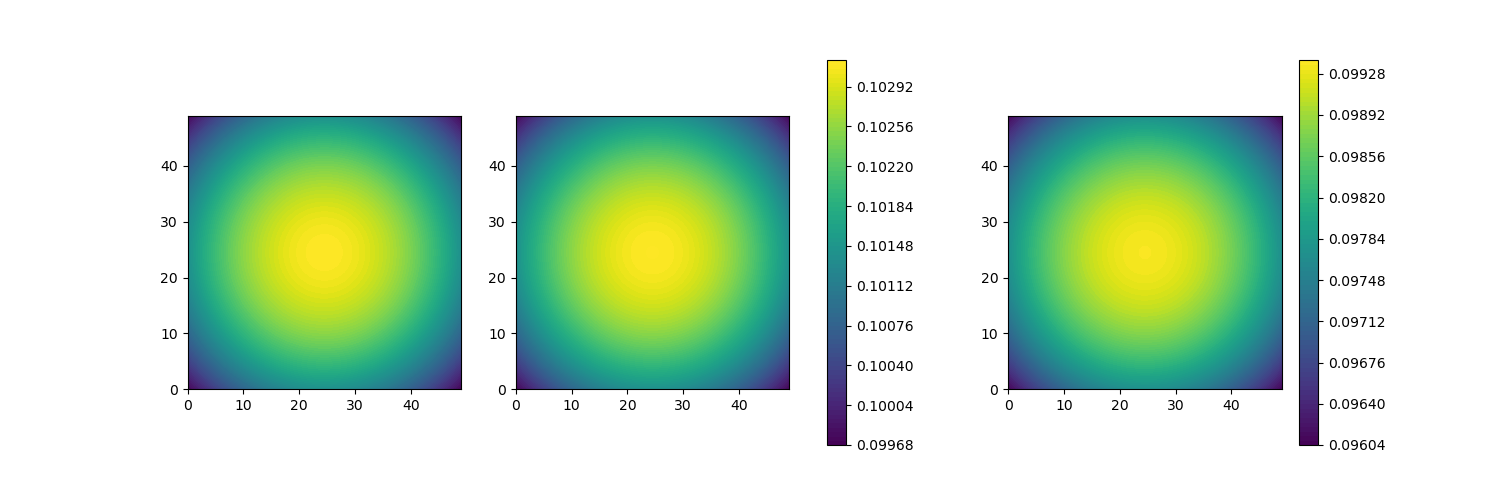

In [43]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 23
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = res_density.squeeze().detach().cpu().numpy()[idx]
dens2d = dens2d.reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = sample['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')
print(result['density'].shape)

p_dens = sample_df['density'].squeeze()

p_dens = p_dens[idx].reshape(50, 50)
vmin = np.min(p_dens.numpy())
vmax = np.max(p_dens.numpy())

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
#plt.savefig('figures/target_vs_result.pdf', dpi=300)
plt.show()